In [1]:
import numpy as np
import pandas as pd
import pickle
from netCDF4 import Dataset
from scipy.interpolate import RegularGridInterpolator
import geopandas as gpd
from shapely.ops import polygonize, unary_union
from shapely.geometry import Polygon, MultiPolygon
from matplotlib.path import Path
from pygam import GAM, LinearGAM, s, l
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. Load data
# ============================================================================
print('Loading data...')

# SLA
file_id = Dataset('../../data/sla/sla_2018_l4_4k.nc')
sla_data = file_id.variables["sla"][:].filled(np.nan).astype('float64')
sla_lat  = file_id.variables["latitude"][:].copy()
sla_lon  = file_id.variables["longitude"][:].copy()
sla_time = file_id.variables["time"][:].copy()
sla_time_units = file_id.variables["time"].units
file_id.close()

# SST
file_id = Dataset('../../data/sst/sst_2018_l3_4k.nc')
sst_data = file_id.variables["adjusted_sea_surface_temperature"][:].filled(np.nan).astype('float64')
sst_lat  = file_id.variables["latitude"][:].copy()
sst_lon  = file_id.variables["longitude"][:].copy()
sst_time = file_id.variables["time"][:].copy()
file_id.close()

# CHL
file_id = Dataset('../../data/chl/chl_2018_daily_multi_l3_4k.nc')
chl_data = file_id.variables["CHL"][:].filled(np.nan).astype('float64')
chl_lat  = file_id.variables["latitude"][:].copy()
chl_lon  = file_id.variables["longitude"][:].copy()
chl_time = file_id.variables["time"][:].copy()
file_id.close()

# Clean fill values
sla_data[np.abs(sla_data) > 900] = np.nan
sst_data[np.abs(sst_data) > 900] = np.nan
chl_data[chl_data > 900] = np.nan

print(f'SLA shape: {sla_data.shape}, lat: {len(sla_lat)}, lon: {len(sla_lon)}')
print(f'SST shape: {sst_data.shape}, lat: {len(sst_lat)}, lon: {len(sst_lon)}')
print(f'CHL shape: {chl_data.shape}, lat: {len(chl_lat)}, lon: {len(chl_lon)}')


Loading data...
SLA shape: (154, 136, 320), lat: 136, lon: 320
SST shape: (154, 170, 400), lat: 170, lon: 400
CHL shape: (154, 408, 960), lat: 408, lon: 960


In [2]:

# ============================================================================
# 2. Build date vectors
# ============================================================================
sla_timedelta = (sla_time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
sla_dates = np.datetime64('1950-01-01') + sla_timedelta

sst_timedelta = (sst_time * np.timedelta64(1, 's')).astype('timedelta64[ns]')
sst_dates = np.datetime64('1981-01-01') + sst_timedelta

chl_timedelta = (chl_time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
chl_dates = np.datetime64('1900-01-01') + chl_timedelta


In [3]:
# ============================================================================
# 3. Resample SST and CHL to SLA grid (nearest neighbor)
# ============================================================================
print('Resampling SST and CHL to SLA grid...')

# Find common dates across all three datasets
sla_date_set = set(sla_dates.astype('datetime64[D]'))
sst_date_set = set(sst_dates.astype('datetime64[D]'))
chl_date_set = set(chl_dates.astype('datetime64[D]'))
common_dates = sorted(sla_date_set & sst_date_set & chl_date_set)
common_dates = np.array(common_dates)

print(f'Common dates: {len(common_dates)} '
      f'({str(common_dates[0])[:10]} to {str(common_dates[-1])[:10]})')

# Index into each dataset for common dates
sla_idx = np.array([np.where(sla_dates.astype('datetime64[D]') == d)[0][0]
                     for d in common_dates])
sst_idx = np.array([np.where(sst_dates.astype('datetime64[D]') == d)[0][0]
                     for d in common_dates])
chl_idx = np.array([np.where(chl_dates.astype('datetime64[D]') == d)[0][0]
                     for d in common_dates])

# Resample SST and CHL to SLA lat/lon using nearest neighbor
def resample_to_grid(data, src_lat, src_lon, dst_lat, dst_lon):
    """Resample 3D array (time, lat, lon) to new lat/lon grid via nearest neighbor."""
    resampled = np.full((data.shape[0], len(dst_lat), len(dst_lon)), np.nan)
    for t in range(data.shape[0]):
        interp = RegularGridInterpolator(
            (src_lat, src_lon), data[t, :, :],
            method='nearest', bounds_error=False, fill_value=np.nan
        )
        dst_lon_grid, dst_lat_grid = np.meshgrid(dst_lon, dst_lat)
        pts = np.column_stack((dst_lat_grid.ravel(), dst_lon_grid.ravel()))
        resampled[t, :, :] = interp(pts).reshape(len(dst_lat), len(dst_lon))
    return resampled

sst_resampled = resample_to_grid(sst_data[sst_idx], sst_lat, sst_lon, sla_lat, sla_lon)
chl_resampled = resample_to_grid(chl_data[chl_idx], chl_lat, chl_lon, sla_lat, sla_lon)
sla_subset    = sla_data[sla_idx]

# print(f'Resampled shapes — SLA: {sla_subset.shape}, SST: {sst_resampled.shape}, CHL: {chl_resampled.shape}')

Resampling SST and CHL to SLA grid...
Common dates: 154 (2018-06-01 to 2018-11-01)


In [4]:
# ============================================================================
# 4. Mask the CZ around Hawaiian Islands
# ============================================================================
gdf = gpd.read_file('../../data/eez/USMaritimeLimitsNBoundaries.shp')
hawaii = gdf[gdf['REGION'] == 'Hawaiian Islands']
cz_lines = hawaii[hawaii['CZ'] == 1.0]
merged_lines = unary_union(cz_lines.geometry)
cz_polys = list(polygonize(merged_lines))
cz_combined = unary_union(cz_polys)

lon_grid, lat_grid = np.meshgrid(sla_lon, sla_lat)
points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))

if isinstance(cz_combined, Polygon):
    cz_combined = MultiPolygon([cz_combined])

inside = np.zeros(len(points), dtype=bool)
for poly in cz_combined.geoms:
    p = Path(np.array(poly.exterior.coords))
    inside |= p.contains_points(points)
inside = inside.reshape(lon_grid.shape)

# Apply mask to all three variables
sla_subset[:, inside]    = np.nan
sst_resampled[:, inside] = np.nan
chl_resampled[:, inside] = np.nan


Plotting time step 10: 2018-06-11


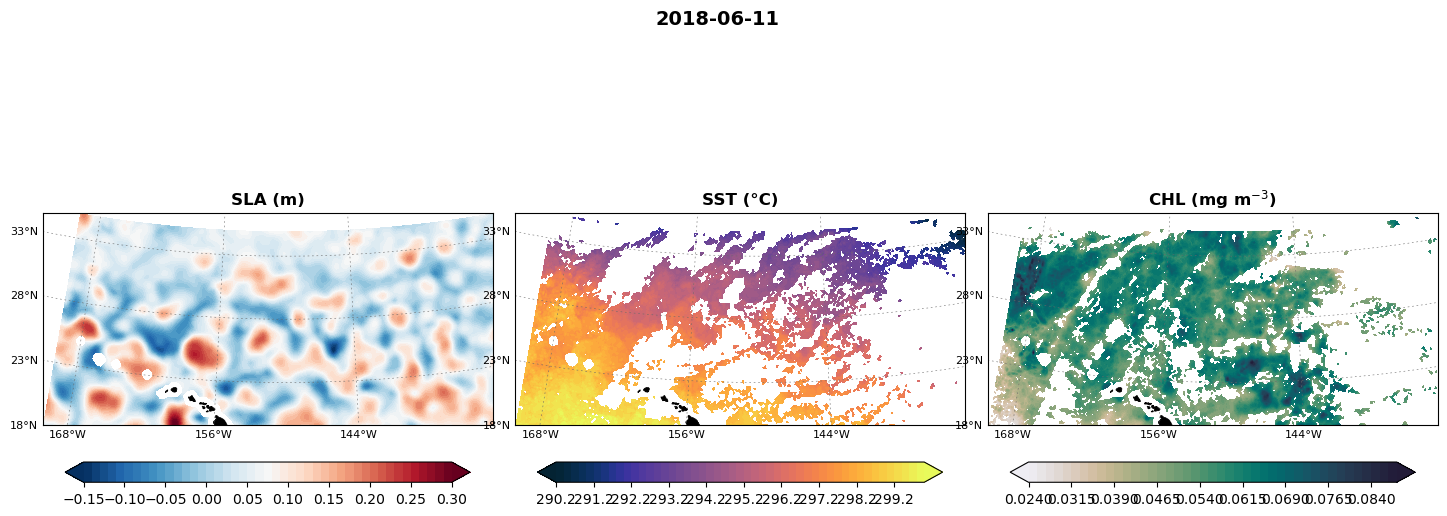

In [5]:
import matplotlib.pyplot as plt
import cmocean
from mpl_toolkits.basemap import Basemap

# Pick a common time step to plot
t = 10  # change to check different days
print(f'Plotting time step {t}: {str(common_dates[t])[:10]}')

lon_grid, lat_grid = np.meshgrid(sla_lon, sla_lat)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (sla_subset[t, :, :],    'SLA (m)',           'RdBu_r'),
    (sst_resampled[t, :, :], 'SST (°C)',          cmocean.cm.thermal),
    (chl_resampled[t, :, :], 'CHL (mg m$^{-3}$)', cmocean.cm.rain),
]

for ax, (data, title, cmap) in zip(axs, datasets):
    m = Basemap(projection='lcc', resolution='h',
                llcrnrlat=18, urcrnrlat=35,
                llcrnrlon=-170, urcrnrlon=-130,
                lat_0=30, lon_0=-150,
                width=5.1E6, height=5E6,
                ax=ax)

    x, y = m(lon_grid, lat_grid)
    cp = m.contourf(x, y, data, levels=50, cmap=cmap, extend='both')
    m.drawcoastlines(color='black', linewidth=0.5)
    m.fillcontinents(color='black')
    m.drawparallels(np.arange(18, 40, 5), labels=[1, 0, 0, 0],
                    color='dimgrey', fontsize=8, dashes=(3, 5), linewidth=0.4)
    m.drawmeridians(np.arange(-168, -135, 12), labels=[0, 0, 0, 1],
                    color='dimgrey', fontsize=8, dashes=(3, 5), linewidth=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    fig.colorbar(cp, ax=ax, orientation='horizontal', pad=0.08, shrink=0.9)

plt.suptitle(f'{str(common_dates[t])[:10]}', fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.05)
plt.show()

In [6]:
# ============================================================================
# 5. Build dataframe
# ============================================================================
print('Building dataframe...')

# Day of year for time smooth
doy = np.array([(np.datetime64(d, 'D') - np.datetime64(str(d)[:4], 'Y')).astype(int) + 1
                for d in common_dates])

ntime = len(common_dates)
nlat  = len(sla_lat)
nlon  = len(sla_lon)

# Flatten all arrays
time_flat = np.repeat(doy, nlat * nlon)
lon_flat  = np.tile(lon_grid.ravel(), ntime)
lat_flat  = np.tile(lat_grid.ravel(), ntime)
sla_flat  = sla_subset.ravel()
sst_flat  = sst_resampled.ravel()
chl_flat  = chl_resampled.ravel()

alldata = pd.DataFrame({
    'time': time_flat,
    'lon': lon_flat,
    'lat': lat_flat,
    'sla': sla_flat,
    'sst': sst_flat,
    'chl': chl_flat
})

# Remove rows where any variable is NaN
alldata = alldata.dropna().reset_index(drop=True)
print(f'Total observations after removing NaN: {len(alldata)}')

# Free memory
del sla_subset, sst_resampled, chl_resampled
del sla_data, sst_data, chl_data

Building dataframe...
Total observations after removing NaN: 2097470


In [ ]:
# ============================================================================
# 6. Subsample for tractable GAM fitting
# ============================================================================
n_sample = min(100000, len(alldata))
print(f'Subsampling to {n_sample} observations...')
smalldata = alldata.sample(n=n_sample, random_state=42).reset_index(drop=True)

# Option 1: Subset by day of year
start_doy = 180  # ~June somehting
end_doy   = 260  # ~October 30
subset = smalldata[(smalldata['time'] >= start_doy) & (smalldata['time'] <= end_doy)]

Subsampling to 100000 observations...


In [11]:
from pygam import GAM, LinearGAM, s, l, te

# ============================================================================
# 7. Fit GAMs
# ============================================================================
print('Fitting GAM: CHL ~ SLA + s(time) + s(lon, lat)...')

# GAM 1: CHL ~ SLA + s(time) + s(lon, lat)
X_chl = subset[['sla', 'time', 'lon', 'lat']].values
y_chl = subset['chl'].values

# GAM 1: CHL ~ SLA + s(time) + te(lon, lat)
gam_chl = GAM(
    l(0) + s(1, n_splines=10) + te(2, 3, n_splines=[4, 4]),
    distribution='gamma',
    link='inverse'
)
gam_chl.fit(X_chl, y_chl)

# GAM 2: SST ~ SLA + s(time) + s(lon, lat)
X_sst = subset[['sla', 'time', 'lon', 'lat']].values
y_sst = subset['sst'].values

# GAM 2: SST ~ SLA + s(time) + te(lon, lat)
gam_sst = LinearGAM(
    l(0) + s(1, n_splines=4) + te(2, 3, n_splines=[4, 4])
)
gam_sst.fit(X_sst, y_sst)

print('  Done.')
print(gam_sst.summary())


Fitting GAM: CHL ~ SLA + s(time) + s(lon, lat)...
  Done.
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     11.4038
Link Function:                     IdentityLink Log Likelihood:                                -25427.0724
Number of Samples:                        48559 AIC:                                            50878.9524
                                                AICc:                                           50878.9593
                                                GCV:                                                 0.167
                                                Scale:                                              0.4085
                                                Pseudo R-Squared:                     


  CHL ~ SLA — GAM Results
  SLA linear slope: 1.172053
  Model R²: 0.1986



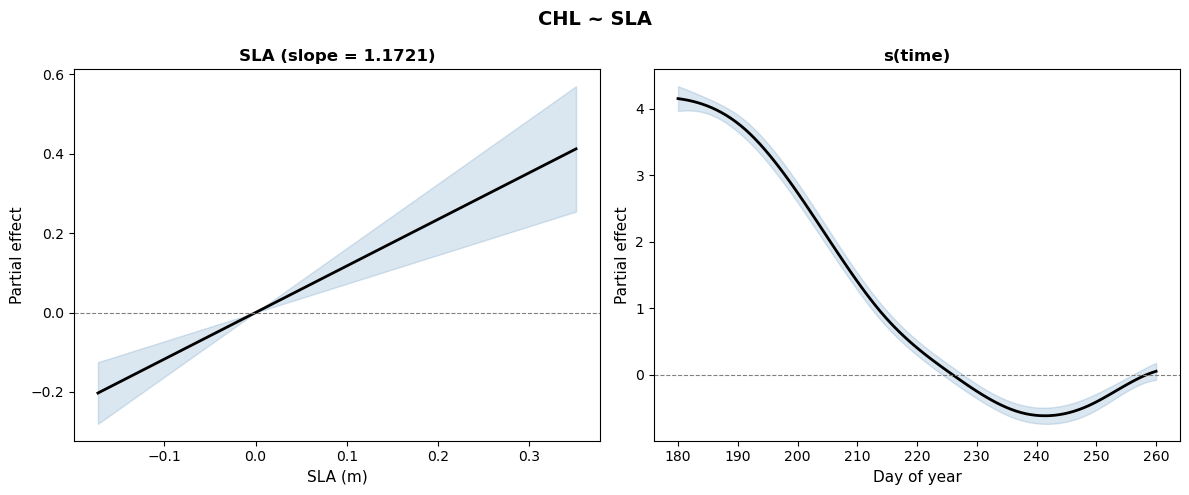

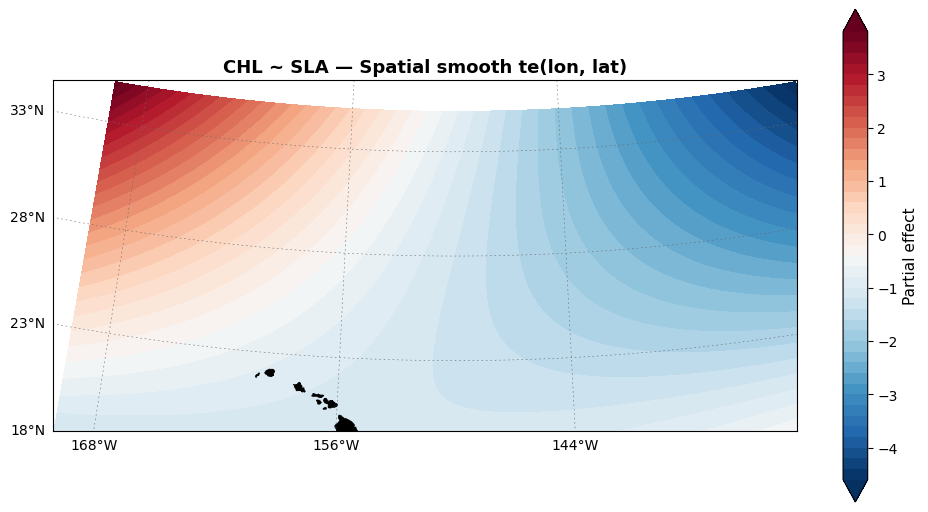


  SST ~ SLA — GAM Results
  SLA linear slope: 1.036589
  Model R²: 0.9471



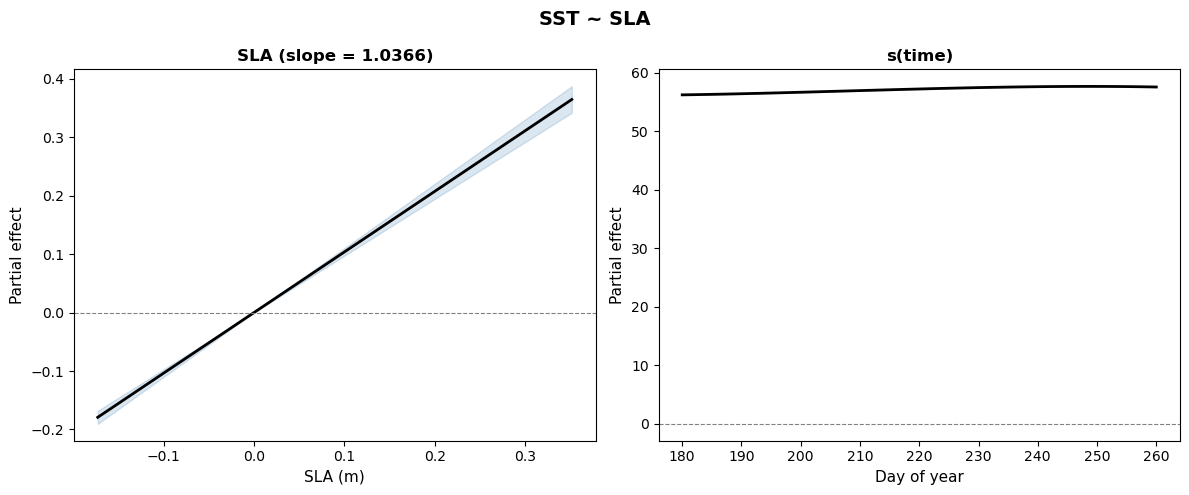

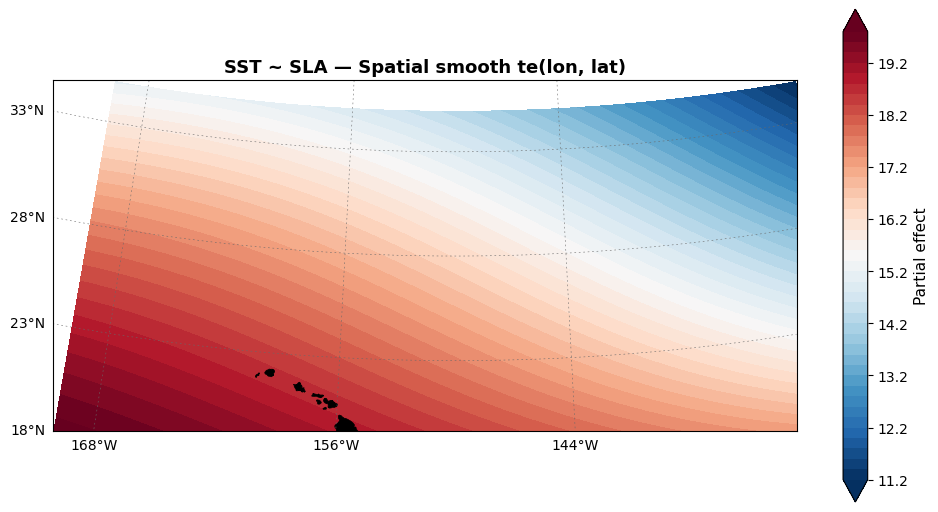

In [12]:
def plot_gam_results(gam_model, feature_names, model_name, sla_lon, sla_lat):
    """
    Plot GAM results: linear term slope, partial dependence plots,
    and spatial smooth as a map.
    """

    # -- Extract and print linear term slope --
    coef = gam_model.coef_[0]
    print(f'\n{"="*60}')
    print(f'  {model_name} — GAM Results')
    print(f'{"="*60}')
    print(f'  SLA linear slope: {coef:.6f}')
    print(f'  Model R²: {gam_model.statistics_["pseudo_r2"]["explained_deviance"]:.4f}')
    print(f'{"="*60}\n')

    # -- Figure 1: Partial dependence plots for SLA and time --
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: SLA linear term
    ax = axs[0]
    XX = gam_model.generate_X_grid(term=0, meshgrid=False)
    pdep, confi = gam_model.partial_dependence(term=0, X=XX, width=0.95)
    x_vals = XX[:, 0]
    ax.plot(x_vals, pdep, color='black', linewidth=2)
    ax.fill_between(x_vals, confi[:, 0], confi[:, 1], alpha=0.2, color='steelblue')
    ax.set_xlabel('SLA (m)', fontsize=11)
    ax.set_ylabel('Partial effect', fontsize=11)
    ax.set_title(f'SLA (slope = {coef:.4f})', fontsize=12, fontweight='bold')
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

    # Panel 2: s(time) smooth
    ax = axs[1]
    XX = gam_model.generate_X_grid(term=1, meshgrid=False)
    pdep, confi = gam_model.partial_dependence(term=1, X=XX, width=0.95)
    x_vals = XX[:, 1]
    ax.plot(x_vals, pdep, color='black', linewidth=2)
    ax.fill_between(x_vals, confi[:, 0], confi[:, 1], alpha=0.2, color='steelblue')
    ax.set_xlabel('Day of year', fontsize=11)
    ax.set_ylabel('Partial effect', fontsize=11)
    ax.set_title('s(time)', fontsize=12, fontweight='bold')
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

    plt.suptitle(f'{model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'gam_partial_{model_name.replace(" ", "_")}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # -- Figure 2: Spatial smooth on a map --
    # Build a grid over the lon/lat range
    lon_vals = np.linspace(sla_lon.min(), sla_lon.max(), 100)
    lat_vals = np.linspace(sla_lat.min(), sla_lat.max(), 100)
    lon_mesh, lat_mesh = np.meshgrid(lon_vals, lat_vals)

    # Create prediction grid: hold SLA at median, time at median
    grid_points = np.column_stack([
        np.full(lon_mesh.ravel().shape, np.median(smalldata['sla'])),
        np.full(lon_mesh.ravel().shape, np.median(smalldata['time'])),
        lon_mesh.ravel(),
        lat_mesh.ravel()
    ])

    # Predict partial effect of spatial term
    pdep = gam_model.partial_dependence(term=2, X=grid_points, width=0.95)[0]
    pdep_grid = pdep.reshape(lon_mesh.shape)

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    m = Basemap(projection='lcc', resolution='h',
                llcrnrlat=18, urcrnrlat=35,
                llcrnrlon=-170, urcrnrlon=-130,
                lat_0=30, lon_0=-150,
                width=5.1E6, height=5E6,
                ax=ax)

    x, y = m(lon_mesh, lat_mesh)
    cp = m.contourf(x, y, pdep_grid, levels=50, cmap='RdBu_r', extend='both')
    m.drawcoastlines(color='black', linewidth=0.5)
    m.fillcontinents(color='black')
    m.drawparallels(np.arange(18, 40, 5), labels=[1, 0, 0, 0],
                    color='dimgrey', fontsize=10, dashes=(3, 5), linewidth=0.4)
    m.drawmeridians(np.arange(-168, -135, 12), labels=[0, 0, 0, 1],
                    color='dimgrey', fontsize=10, dashes=(3, 5), linewidth=0.4)

    cbar = fig.colorbar(cp, shrink=0.8, pad=0.05)
    cbar.set_label('Partial effect', fontsize=11)
    ax.set_title(f'{model_name} — Spatial smooth te(lon, lat)',
                 fontsize=13, fontweight='bold')

    # plt.savefig(f'gam_spatial_{model_name.replace(" ", "_")}.png', dpi=200, bbox_inches='tight')
    plt.show()


# -- Call for both models --
plot_gam_results(gam_chl, ['sla', 'time', 'lon', 'lat'], 'CHL ~ SLA', sla_lon, sla_lat)
plot_gam_results(gam_sst, ['sla', 'time', 'lon', 'lat'], 'SST ~ SLA', sla_lon, sla_lat)

In [ ]:
# ============================================================================
# 8. Save models and data
# ============================================================================
# print('Saving...')

with open('../../data/gam/gam_chl_sla.pkl', 'wb') as f:
    pickle.dump(gam_chl, f)

with open('../../data/gam/gam_sst_sla.pkl', 'wb') as f:
    pickle.dump(gam_sst, f)

smalldata.to_csv('../../data/gam/gam_input_data.csv', index=False)

print('Saved models and data.')
print('Complete.')